# Alzheimer's Disease Detection from Speech - eGeMAPS + XGBoost Pipeline

**Dataset:** ADReSSo-2021 (Alzheimer's Dementia Recognition through Spontaneous Speech)  
**Task:** Binary classification — AD (Alzheimer's Disease) vs. HC (Healthy Control)  
**Features:** 88 eGeMAPS v02 acoustic features  
**Classifier:** XGBoost with StratifiedKFold cross-validation

---

## Pipeline Overview
1. **Load & prepare data** → Build manifests from train/test splits
2. **Audio preprocessing** → Load, VAD, normalize
3. **Feature extraction** → Extract eGeMAPS v02 using openSMILE
4. **Dataset preparation** → Build feature matrices (X, y)
5. **Model training** → XGBoost with k-fold CV
6. **Evaluation** → Confusion matrix, ROC curve, feature importance

---

## Section 0: Setup and Dependencies

Import all required libraries for audio processing, machine learning, and visualization.

In [86]:
# ── Standard library ─────────────────────────────────────────
import os
import re
import glob
import pickle
import random
import warnings
import time
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Data science ──────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# ── Audio ─────────────────────────────────────────────────────
import librosa
import librosa.display
import opensmile

# ── Machine learning ─────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, classification_report
)
import xgboost as xgb
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib

# ── XAI ───────────────────────────────────────────────────────
import shap

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm

# Version report
print(f'numpy       {np.__version__}')
print(f'librosa     {librosa.__version__}')
print(f'opensmile   {opensmile.__version__}')
print(f'xgboost     {xgb.__version__}')
print(f'shap        {shap.__version__}')
print(f'sklearn     {__import__("sklearn").__version__}')

numpy       2.4.4
librosa     0.11.0
opensmile   2.6.0
xgboost     3.2.0
shap        0.51.0
sklearn     1.8.0


## Section 1: Global Configuration

Define paths to datasets, output directories, and reproducibility parameters.
- **DATA**: Root path to ADReSSo-2021 dataset
- **TRAIN_AD/TRAIN_CN**: Training audio directories (Alzheimer's Disease / Healthy Control)
- **TEST_AUDIO**: Test data directory
- **OUTPUTS_DIR**: Where to save models, results, and figures

In [87]:
# ══════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION — edit these paths to match your Drive
# ══════════════════════════════════════════════════════════════

# Root folder for all project outputs (will be created if it doesn't exist)
PROJECT = Path('C:/Users/pelka/Desktop/Wykrywanie-biomarkerow-glosowych/Alzheimer')

# Root folder of the ADReSSo-2021 dataset on your Drive
DATA = Path('C:/Users/pelka/Desktop/Wykrywanie-biomarkerow-glosowych/Alzheimer/ADReSSo 2021')

# TRAIN
TRAIN_AD   = DATA / 'train' / 'audio' / 'ad'
TRAIN_CN   = DATA / 'train' / 'audio' / 'cn'
LABELS_CSV = DATA / 'train' / 'adresso-train-mmse-scores.csv'

# TEST
TEST_AUDIO         = DATA / 'test-dist' / 'audio'
TEST_RESULTS_TASK1 = DATA / 'test-dist' / 'task1.csv'

# ── Output paths ──────────────────────────────────────────────
OUTPUTS_DIR  = PROJECT / 'outputs'
FEATURES_CSV = OUTPUTS_DIR / 'adresso_egemaps_features.csv'
FIGURES_DIR  = OUTPUTS_DIR / 'figures'
MODELS_DIR   = OUTPUTS_DIR / 'models'
RESULTS_DIR  = OUTPUTS_DIR / 'results'
NLP_CSV      = OUTPUTS_DIR / 'nlp_probabilities.csv'  # optional

# ── Reproducibility ───────────────────────────────────────────
RANDOM_STATE = 42
N_FOLDS      = 5
SAMPLE_RATE  = 16_000
VAD_THRESHOLD_DB = -40  # dB below peak RMS for energy-based VAD

# ── Visualization constants ───────────────────────────────────
COLOR_AD = 'tomato'
COLOR_HC = 'steelblue'
PALETTE  = {'AD': COLOR_AD, 'HC': COLOR_HC}

print('Configuration loaded.')
print(f'  PROJECT : {PROJECT}')
print(f'  DATA    : {DATA}')

Configuration loaded.
  PROJECT : C:\Users\pelka\Desktop\Wykrywanie-biomarkerow-glosowych\Alzheimer
  DATA    : C:\Users\pelka\Desktop\Wykrywanie-biomarkerow-glosowych\Alzheimer\ADReSSo 2021


## Section 2: Data Manifest Building

Build DataFrames that catalog all audio files from train/test splits:
- **build_manifest()**: Scans directories and creates filename + label pairs
- **build_test_manifest()**: Merges test audio filenames with labels from CSV
- Verify: No patient overlap between train and test (data integrity check)

In [88]:
def build_manifest(ad_dir, cn_dir):
    rows = []
    for label, directory in [('AD', ad_dir), ('HC', cn_dir)]:
        for fp in sorted(Path(directory).iterdir()):
            rows.append({
                'filename':   fp.name,
                'label':      label,
            })
    return pd.DataFrame(rows)

def build_test_manifest(test_audio_dir, test_results_csv, split_name: str = 'test') -> pd.DataFrame:
    # lista plików
    df = pd.DataFrame({
        'filename': [fp.name for fp in sorted(Path(test_audio_dir).iterdir())]
    })

    # wczytanie CSV
    results = pd.read_csv(test_results_csv)
    results.columns = results.columns.str.lower().str.strip()

    # przetwarzanie etykiet
    results['filename'] = results['id'].astype(str).str.strip() + '.wav'
    results['dx'] = results['dx'].str.strip().replace({
        'Control': 'HC',
        'ProbableAD': 'AD'
    })

    # merge i wybór kolumn
    df = df.merge(results[['filename', 'dx']], on='filename', how='left')

    return df.rename(columns={'dx': 'label'})


df_train = build_manifest(TRAIN_AD, TRAIN_CN)
df_test  = build_test_manifest(TEST_AUDIO, TEST_RESULTS_TASK1)

# Sanity check: no patient appears in both splits
overlap = set(df_train.filename) & set(df_test.filename)
assert len(overlap) == 0, f'Data leakage! Patients in both splits: {overlap}'

print(f'Train: {len(df_train)} files  (AD={len(df_train[df_train.label=="AD"])}, HC={len(df_train[df_train.label=="HC"])})')
print(f'Test : {len(df_test)} files  (AD={len(df_test[df_test.label=="AD"])}, HC={len(df_test[df_test.label=="HC"])})')
print('No patient ID overlap between train and test.')

Train: 166 files  (AD=87, HC=79)
Test : 71 files  (AD=35, HC=36)
No patient ID overlap between train and test.


## Section 3: Audio Preprocessing & Feature Extraction

Pipeline for each audio file:
1. **load_audio()** → Load and resample to 16 kHz (mono)
2. **energy_vad()** → Remove silence using energy-based Voice Activity Detection (VAD)
3. **normalize_audio()** → Peak normalize to [-1, 1]
4. **extract_features_from_signal()** → Extract 88 eGeMAPS v02 features using openSMILE
5. **preprocess_and_extract()** → Complete pipeline wrapper

In [89]:
def load_audio(filepath: str, target_sr: int = SAMPLE_RATE):
    """Load audio, resample to target_sr, convert to mono."""
    try:
        y, sr = librosa.load(filepath, sr=target_sr, mono=True)
        return y, sr
    except Exception as e:
        print(f'[WARN] Could not load {filepath}: {e}')
        return None, None


def energy_vad(y: np.ndarray, sr: int,
               threshold_db: float = VAD_THRESHOLD_DB,
               frame_length: int = 2048,
               hop_length: int = 512) -> np.ndarray:
    """
    Energy-based Voice Activity Detection.

    Algorithm:
      1. Compute RMS energy per frame
      2. Convert to dB relative to peak: rms_db = 20*log10(rms/rms_max)
      3. Build voiced sample mask from frames exceeding threshold_db
      4. Return y[mask] or full y if VAD is too aggressive (<0.5 s result)
    """
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    rms_db = 20 * np.log10(rms / (rms.max() + 1e-9) + 1e-9)
    voiced_frames = rms_db >= threshold_db

    voiced_mask = np.zeros(len(y), dtype=bool)
    for i, is_voiced in enumerate(voiced_frames):
        if is_voiced:
            start = i * hop_length
            end   = min(start + frame_length, len(y))  # guard last frame
            voiced_mask[start:end] = True

    y_voiced = y[voiced_mask]
    # Fallback: if too little signal remains (<0.5 s), return original
    if len(y_voiced) < sr * 0.5:
        print('[WARN] VAD removed >99% of signal — returning original audio')
        return y
    return y_voiced


def normalize_audio(y: np.ndarray) -> np.ndarray:
    """Peak-normalize to [-1, 1]."""
    peak = np.abs(y).max()
    return y / peak if peak > 0 else y

smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals,
)

def extract_features_from_signal(y: np.ndarray, sr: int):
    try:
        feats = smile.process_signal(y, sr)
        return feats.iloc[0]  # jedna linia Functionals
    except Exception as e:
        print(f'[ERROR] openSMILE failed on signal: {e}')
        return None



def trim_audio(
    y: np.ndarray,
    sr: int,
    trim_start_sec: float = 0.0,
    trim_end_sec: float = 0.0,
    min_duration_sec: float = 0.5
):
    """
    Trim audio from beginning and end, with minimum duration constraint.

    Args:
        y: signal
        sr: sampling rate
        trim_start_sec: seconds to remove from start
        trim_end_sec: seconds to remove from end
        min_duration_sec: minimum allowed duration after trimming

    Returns:
        trimmed signal (or original if too short)
    """
    start = int(trim_start_sec * sr)
    end = len(y) - int(trim_end_sec * sr)

    # zabezpieczenie podstawowe
    if start >= end:
        return y

    y_trimmed = y[start:end]

    # ✅ ograniczenie minimalnej długości
    min_samples = int(min_duration_sec * sr)

    if len(y_trimmed) < min_samples:
        # fallback: zwróć oryginał zamiast zbyt krótkiego sygnału
        return y

    return y_trimmed



def preprocess_and_extract(
    filepath,
    apply_vad=False,
    normalize=False,
    trim_start_sec=7,
    trim_end_sec=3,
    min_duration_sec=30
):
    """
    Full pipeline:
    load → trim → VAD → normalize → eGeMAPS

    Returns:
        pd.Series (features) or None
    """

    # ── LOAD ─────────────────────────────────────────────
    y, sr = load_audio(filepath)
    if y is None:
        return None

    # ── TRIM ─────────────────────────────────────────────
    if trim_start_sec > 0 or trim_end_sec > 0:
        y = trim_audio(
            y, sr,
            trim_start_sec=trim_start_sec,
            trim_end_sec=trim_end_sec,
            min_duration_sec=min_duration_sec
        )

    # ── VAD ─────────────────────────────────────────────
    if apply_vad:
        y = energy_vad(y, sr)

    # check po VAD
    if len(y) < int(min_duration_sec * sr):
        return None

    # ── NORMALIZE ───────────────────────────────────────
    if normalize:
        y = normalize_audio(y)

    # ── FEATURE EXTRACTION ──────────────────────────────
    feats = extract_features_from_signal(y, sr)

    return feats

## Section 4: XGBoost Dataset Preparation

Extract features for all samples and build training/test matrices:
- **Input**: df_train, df_test with filenames and labels
- **Process**: For each file, extract 88 eGeMAPS features
- **Output**: 
  - X_train: (N_train, 88) feature matrix
  - y_train: (N_train,) labels (0=HC, 1=AD)
  - X_test, y_test: Same for test set
- **Handling**: Skip files with failed extraction or NaN values

In [90]:
def prepare_xgboost_dataset(df_train, df_test, data_dir_train_ad, data_dir_train_cn,
                            data_dir_test, apply_vad=False, normalize=True):

    label_encoder = {'HC': 0, 'AD': 1}

    # ── TRAIN ─────────────────────────────────────────────
    train_features, train_labels = [], []

    for _, row in df_train.iterrows():
        filename = row['filename']
        label = row['label']

        filepath = Path(data_dir_train_ad if label == 'AD' else data_dir_train_cn) / filename

        feats = preprocess_and_extract(str(filepath), apply_vad=apply_vad, normalize=normalize)

        if feats is not None and not feats.isnull().all():
            train_features.append(feats.values)
            train_labels.append(label_encoder[label])

    X_train = np.array(train_features)
    y_train = np.array(train_labels)

    # ── TEST ──────────────────────────────────────────────
    test_features, test_labels = [], []

    for _, row in df_test.iterrows():
        filename = row['filename']
        label = row['label']

        filepath = Path(data_dir_test) / filename

        feats = preprocess_and_extract(str(filepath), apply_vad=apply_vad, normalize=normalize)

        if feats is not None and not feats.isnull().all():
            test_features.append(feats.values)
            if label in label_encoder:
                test_labels.append(label_encoder[label])

    X_test = np.array(test_features) if test_features else None
    y_test = np.array(test_labels) if test_labels else None

    
    # ── PODSUMOWANIE ──────────────────────────────────────
    print("\n" + "=" * 60)
    print("DATASET SUMMARY")
    print("=" * 60)
    
    print(f"Train samples: {X_train.shape[0]}")
    print(f"Train features per sample: {X_train.shape[1] if X_train.size > 0 else 0}")
    print(f"Train class distribution: HC={np.sum(y_train==0)}, AD={np.sum(y_train==1)}")


    print(f"\nTest samples: {X_test.shape[0]}")
    print(f"Test features per sample: {X_test.shape[1] if X_test.size > 0 else 0}")
    print(f"Test class distribution: HC={np.sum(y_test==0)}, AD={np.sum(y_test==1)}")

    print("=" * 60)

    # ── OUTPUT ────────────────────────────────────────────
    return X_train, y_train, X_test, y_test


## Section 5: Build Feature Matrices

Execute the dataset preparation function to create training and test feature matrices.

In [91]:
X_train, y_train, X_test, y_test = prepare_xgboost_dataset(
    df_train, df_test,
    TRAIN_AD, TRAIN_CN, TEST_AUDIO,
    apply_vad=False,
    normalize=True
)


DATASET SUMMARY
Train samples: 163
Train features per sample: 88
Train class distribution: HC=76, AD=87

Test samples: 64
Test features per sample: 88
Test class distribution: HC=33, AD=31


## Section 6: XGBoost Training with K-Fold Cross-Validation

Main training function:
- **Grid Search** (optional): Tune hyperparameters if best_params contains lists
- **StratifiedKFold**: k-fold cross-validation (default: 5 folds) to assess generalization
- **Final Model**: Train on full training set with best hyperparameters
- **Test Evaluation**: Report accuracy and F1-score on held-out test set

In [92]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import xgboost as xgb


def train_xgboost_kfold(X_train, y_train, X_test=None, y_test=None,
                        n_splits=5, best_params=None):

    # ✅ obsługa wersji XGBoost
    xgb_ver = tuple(int(x) for x in xgb.__version__.split('.')[:2])
    xgb_extra_kwargs = {} if xgb_ver >= (2, 0) else {'use_label_encoder': False}

    # ── DETECT: czy to grid czy konkretne parametry ───────
    is_grid = any(isinstance(v, list) for v in best_params.values()) if best_params else False

    # ── GRID SEARCH ───────────────────────────────────────
    if is_grid:
        print("\nRunning GridSearchCV...")

        base_model = XGBClassifier(
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1,
            **xgb_extra_kwargs
        )

        gs = GridSearchCV(
            base_model,
            best_params,
            cv=3,
            scoring='f1',
            n_jobs=-1,
            verbose=1
        )

        gs.fit(X_train, y_train)
        best_params = gs.best_params_

        print("\nBest params:", best_params)
        print(f"Best CV F1: {gs.best_score_:.4f}")

    # ── K-FOLD ────────────────────────────────────────────
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_acc = []
    fold_f1  = []

    print("\n" + "=" * 60)
    print("K-FOLD TRAINING")
    print("=" * 60)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = XGBClassifier(
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1,
            **(best_params if best_params else {}),
            **xgb_extra_kwargs
        )

        model.fit(X_tr, y_tr)

        preds = model.predict(X_val)

        acc = accuracy_score(y_val, preds)
        f1  = f1_score(y_val, preds)

        fold_acc.append(acc)
        fold_f1.append(f1)

        print(f"Fold {fold}: ACC={acc:.4f}, F1={f1:.4f}")

    print("\nMean CV Accuracy:", np.mean(fold_acc))
    print("Mean CV F1      :", np.mean(fold_f1))

    # ── FINAL MODEL ───────────────────────────────────────
    print("\nTraining final model on full dataset...")

    final_model = XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        **(best_params if best_params else {}),
        **xgb_extra_kwargs
    )

    final_model.fit(X_train, y_train)

    # ── TEST ──────────────────────────────────────────────
    if X_test is not None and y_test is not None:
        preds_test = final_model.predict(X_test)

        acc_test = accuracy_score(y_test, preds_test)
        f1_test  = f1_score(y_test, preds_test)

        print("\n" + "=" * 60)
        print("TEST RESULTS")
        print("=" * 60)
        print(f"Accuracy: {acc_test:.4f}")
        print(f"F1-score: {f1_test:.4f}")

    return final_model

## Section 7: Train Final Model with Optimized Hyperparameters

Set hyperparameters and train the final XGBoost model using k-fold cross-validation.

In [93]:
params = {
    'n_estimators': 200,
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1
}
model = train_xgboost_kfold(
    X_train, y_train,
    X_test, y_test,
    best_params=params,
)


K-FOLD TRAINING
Fold 1: ACC=0.6970, F1=0.7368
Fold 2: ACC=0.7273, F1=0.7429
Fold 3: ACC=0.6667, F1=0.7179
Fold 4: ACC=0.7500, F1=0.7647
Fold 5: ACC=0.7812, F1=0.7879

Mean CV Accuracy: 0.7244318181818181
Mean CV F1      : 0.7500465272601495

Training final model on full dataset...

TEST RESULTS
Accuracy: 0.7344
F1-score: 0.7119


## Section 8: Model Evaluation & Visualization Functions

Define reusable functions for model interpretation:
- **plot_confusion()** → Confusion matrix (TP, TN, FP, FN)
- **plot_roc()** → ROC curve with AUC score
- **plot_feature_importance()** → Top N features by XGBoost importance

In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion(model, X_test, y_test):
    preds = model.predict(X_test)

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HC', 'AD'])

    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

from sklearn.metrics import roc_curve, auc

def plot_roc(model, X_test, y_test):
    probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

def plot_feature_importance(model, feature_names, top_n=20):
    importances = model.feature_importances_

    # sortowanie
    idx = importances.argsort()[::-1][:top_n]

    plt.figure(figsize=(10, 6))
    plt.barh(range(top_n), importances[idx][::-1])
    plt.yticks(range(top_n), [feature_names[i] for i in idx][::-1])

    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Feature Importances")
    plt.show()

## Section 9: Generate Final Visualizations

Plot confusion matrix, ROC curve, and feature importance for the trained model.

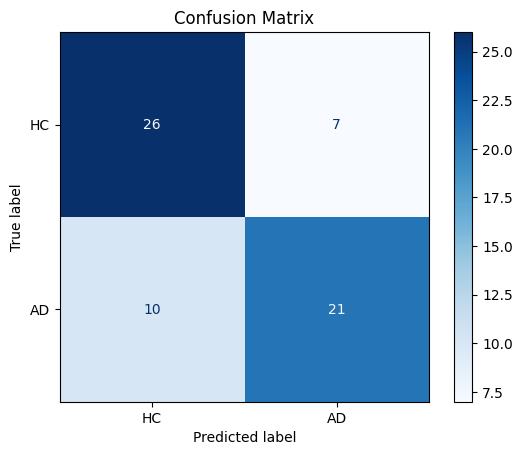

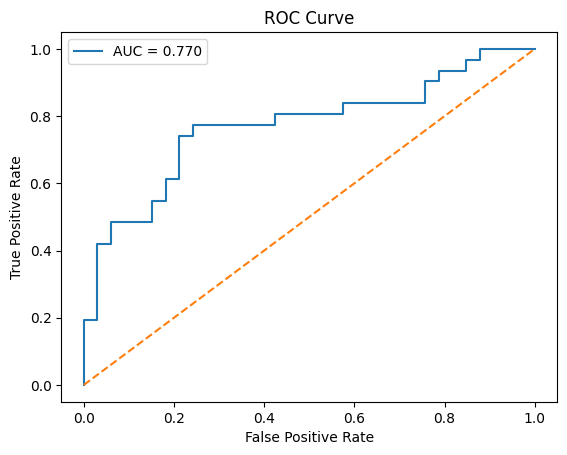

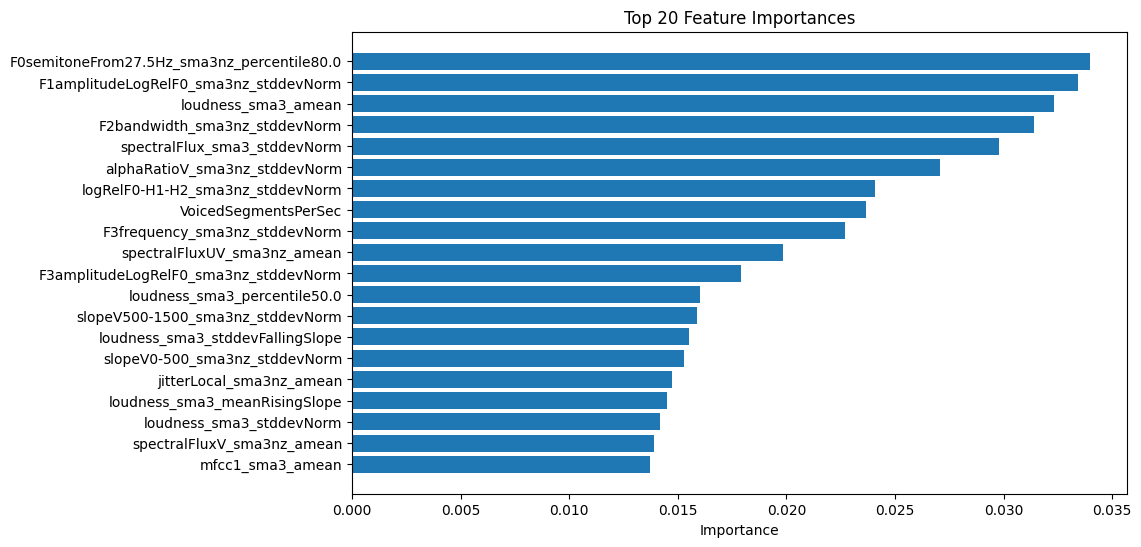

In [95]:

plot_confusion(model, X_test, y_test)
plot_roc(model, X_test, y_test)
plot_feature_importance(model, smile.feature_names)
